<a href="https://colab.research.google.com/github/erinlinglilin000/Financial-Market/blob/main/Tutorial1_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install and import required packages

In [16]:
# Install once: python -m pip install yfinance pandas

In [17]:
import yfinance as yf  # Download Yahoo Finance data.
import pandas as pd  # Calculate returns and summary statistics.

## Get the data

In [36]:
# Download all three series together
series=["^IRX", "AAPL", "MSFT"]
start = "2021-09-30"
end = "2026-10-01"
interval = "1d"

data = yf.download(
    series, start, end, interval=interval, auto_adjust=False, progress=False
)

from google.colab import files

files.download("data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Select adjusted prices on equity trading dates.

In [35]:

prices = data["Adj Close"][["AAPL", "MSFT"]].dropna(how="all")
prices.to_csv("prices.csv")
from google.colab import files
files.download("prices.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (a) Calculate daily share returns:
$$(P_t / P_{t-1}) - 1$$

In [20]:
returns = prices.pct_change(fill_method=None).loc["2021-10-01":]

## Convert the annual Treasury yield to a daily decimal rate

In [37]:

rf = data["Close"]["^IRX"] / 100 / 252
rf.to_csv("rf.csv")
from google.colab import files
files.download("rf.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (b) Calculate excess return
Subtract the same day's risk-free rate; keep common dates.

In [41]:
excess = returns.sub(rf, axis=0).dropna()
excess.to_csv("excess.csv")
from google.colab import files
files.download("excess.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Calculate average excess return, standard deviation of exess returns, and excess return per unit of risk

In [43]:
# Calculate arithmetic mean daily excess returns.
mean = excess.mean()
mean.to_csv("mean.csv")
from google.colab import files
files.download("mean.csv")

 # Calculate sample standard deviations of excess returns.
risk = excess.std(ddof=1)
risk.to_csv("risk.csv")
from google.colab import files
files.download("risk.csv")

 # Calculate daily excess return per unit of risk.
sharpe = mean / risk

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Build the summary table

In [24]:
# Display summary statistics for AAPL and MSFT side by side.
summary = pd.DataFrame({
    "Mean daily excess return (%)": mean * 100,
    "Daily standard deviation (%)": risk * 100,
    "Skewness": excess.skew(),
    "Excess kurtosis": excess.kurt(),
    "Daily Sharpe ratio": sharpe,
    "Annualised Sharpe ratio": sharpe * 252 ** 0.5,  # Apply conventional annualisation.
}).T

# Display the complete statistics table
print(summary.round(4))
print("Higher sample Sharpe ratio:", sharpe.idxmax())

Ticker                          AAPL    MSFT
Mean daily excess return (%)  0.0709  0.0518
Daily standard deviation (%)  1.7674  1.7768
Skewness                      0.3760  0.5775
Excess kurtosis               6.6246  7.1622
Daily Sharpe ratio            0.0401  0.0291
Annualised Sharpe ratio       0.6369  0.4627
Higher sample Sharpe ratio: AAPL


<Axes: title={'center': 'Daily excess returns for AAPL and MSFT'}, xlabel='Date'>

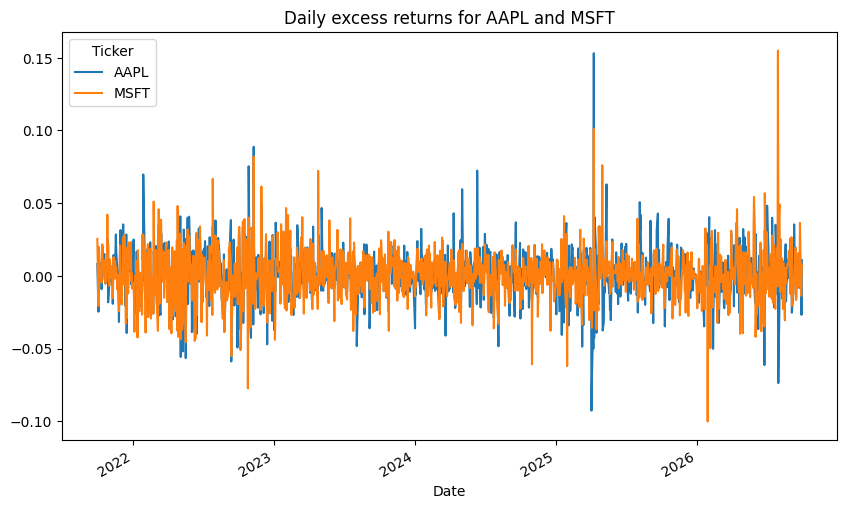

In [25]:
excess.plot(title="Daily excess returns for AAPL and MSFT", figsize=(10, 6))